In [1]:
conda_env = "km3net-event"
import sys
if sys.executable[-27:-15] != conda_env:
    print("Load the correct conda environment: ", conda_env)

From: The KM3NeT event Nature paper, 
https://www.nature.com/articles/s41586-024-08543-1 

The equatorial coordinates (J2000) and the detection time of KM3-230213A are: RA = 94.3°, dec. = −7.8°, MJD = 59988.0533299. The different containment radii are: R(50%) = 1.2°, R(68%) = 1.5°, R(90%) = 2.2° and R(99%) = 3.0°,

For the CRTS search the maximum allowed ROI around  a point is 3' or 0.05°

The aim of this notebook is to create different tiles, i.e. centre with ROI of 0.05°.
This will be used to obtain the light curves of all the sources around the resion of the KM3NeT event.

# Loading required libraries

In [2]:
import numpy as np
print("Numpy version: ", np.__version__)

import pandas as pd
print("Pandas version: ", pd.__version__)

import matplotlib.pyplot as plt
import matplotlib as mpl
print("Matplotlib version: ", mpl.__version__)
mpl.rcParams.update({'font.size': 14})

import astropy
import astropy.units as u
from astropy.coordinates import SkyCoord
print("Astropy version: ", astropy.__version__)

Numpy version:  2.4.4
Pandas version:  3.0.2
Matplotlib version:  3.10.9
Astropy version:  7.2.0


# KM3NeT event co-ordinates

In [3]:
ra0_deg = 94.3
dec0_deg = -7.8
# mjd = 59988.0533299

center = SkyCoord(ra=ra0_deg*u.deg, dec=dec0_deg*u.deg, frame="icrs")

containment_radii_deg = {
    "R50": 1.2,
    "R68": 1.5,
    "R90": 2.2,
    "R99": 3.0,
}

crts_roi_deg = 0.05   # 3 arcmin = 0.05 deg

print(center.to_string("decimal"))

94.3 -7.8


A note on co-ordinate system and reference frames:

* **Coordinate system**: The *geometry and labels* used to specify a position (e.g., spherical RA/Dec or Galactic l/b).
  *Examples*: Equatorial coordinates (RA, Dec), Galactic coordinates (l, b).

* **Reference frame**: The *physical definition and orientation* that anchors those coordinates in space (accounts for epoch, motion, standards).
  *Examples*: ICRS (quasar-based inertial frame), FK5 (star-based frame at a given epoch like J2000).


The International Celestial Reference System (ICRS) is currently the standard, the fifth fundamental catalogue (FK5; specifically the J2000.0 frame) is very close to it, with only small rotational differences (less than 80 microarcseconds).

In [4]:
center

<SkyCoord (ICRS): (ra, dec) in deg
    (94.3, -7.8)>

It is in ICRS, ra, dec

In [5]:
center.transform_to('fk5')

<SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    (94.30000607, -7.8000057)>

Now it is in FK5 J2000 ra, dec

Both ICRS and FK5 frames are in equitorial co-ordinate system.

In [6]:
center.galactic

<SkyCoord (Galactic): (l, b) in deg
    (216.06032168, -11.13496792)>

Now it is in galactic co-ordinates using Milky way lat/longitude. 

# Tile generation

In [7]:
region = "R99"
radius_deg = containment_radii_deg[region]

print(region, radius_deg, "deg")

R99 3.0 deg


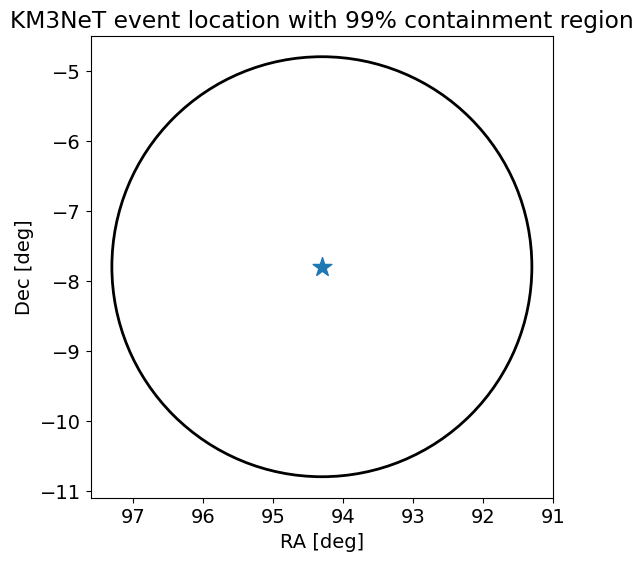

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(ra0_deg, dec0_deg, marker="*", s=200, label="KM3-230213A")
circle = plt.Circle((ra0_deg, dec0_deg), radius_deg, fill=False, linewidth=2)

ax.add_patch(circle)
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title(f"KM3NeT event location with {region[1:]}% containment region")
ax.set_aspect("equal", adjustable="box")
ax.invert_xaxis()
plt.show()

In [9]:
step_deg = crts_roi_deg * 2   # tile diameter spacing

dec_min = dec0_deg - radius_deg
dec_max = dec0_deg + radius_deg

dec_grid = np.arange(dec_min, dec_max + step_deg, step_deg)
tiles = []

for dec in dec_grid:
    # correct RA spacing by cos(dec) since RA is angle on a sphere
    ra_step = step_deg / np.cos(np.deg2rad(dec))
    
    ra_min = ra0_deg - radius_deg / np.cos(np.deg2rad(dec))
    ra_max = ra0_deg + radius_deg / np.cos(np.deg2rad(dec))
    
    ra_grid = np.arange(ra_min, ra_max + ra_step, ra_step)
    
    for ra in ra_grid:
        tile_center = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
        sep_deg = center.separation(tile_center).deg
        
        if sep_deg <= radius_deg:
            tiles.append({
                "RA_deg": ra,
                "Dec_deg": dec,
                "ROI_deg": crts_roi_deg,
                "Separation_deg": sep_deg,
            })

tiles_df = pd.DataFrame(tiles)
print("Total regions", len(tiles_df))
tiles_df.head()

Total regions 2819


,RA_deg,Dec_deg,ROI_deg,Separation_deg
0,94.300000,-10.8,0.05,3.000000
1,93.587614,-10.7,0.05,2.984002
2,93.689383,-10.7,0.05,2.961948
3,93.791153,-10.7,0.05,2.943158
4,93.892922,-10.7,0.05,2.927694


In [10]:
r = tiles_df["Separation_deg"]

tiles_df["Region"] = np.select([r <= 1.2, r <= 1.5, r <= 2.2, r <= 3.0], ["R50", "R68", "R90", "R99"], default="Outside")
tiles_df["Region"].value_counts()

Region
R99    1303
R90     812
R50     440
R68     264
Name: count, dtype: int64

# Plotting tiles

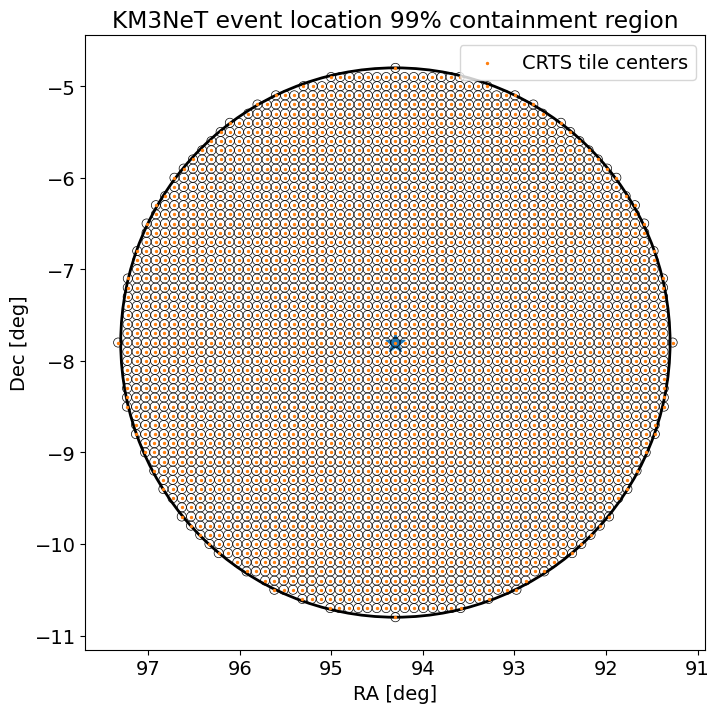

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(ra0_deg, dec0_deg, marker="*", s=200)
circle = plt.Circle( (ra0_deg, dec0_deg), radius_deg, fill=False, linewidth=2)
ax.add_patch(circle)

ax.scatter(tiles_df["RA_deg"], tiles_df["Dec_deg"], s=2, label="CRTS tile centers")
for tile in range(len(tiles_df["RA_deg"])):
    roi_circle = plt.Circle( (tiles_df["RA_deg"][tile], tiles_df["Dec_deg"][tile]), 0.05, fill=False, linewidth=0.5)
    ax.add_patch(roi_circle)

ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title(f"KM3NeT event location {region[1:]}% containment region")
ax.set_aspect("equal", adjustable="box")
ax.invert_xaxis()
ax.legend()
plt.show()

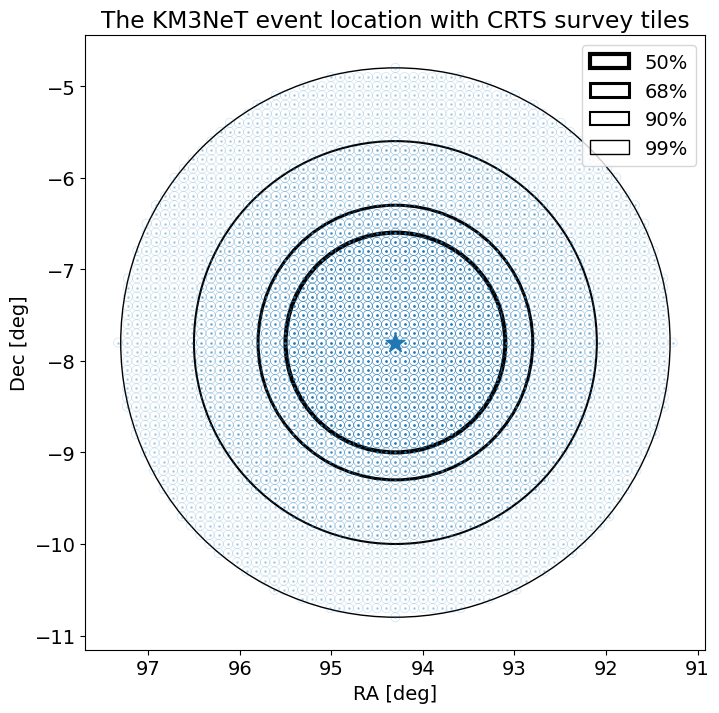

In [12]:
alphas = {"R50": 0.95, "R68": 0.65, "R90": 0.45, "R99": 0.25}
linewidths = {"R50": 3.0, "R68": 2.2, "R90": 1.5, "R99": 1.0}

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(ra0_deg, dec0_deg, marker="*", s=200)

for reg, rad in containment_radii_deg.items():
    ax.add_patch(plt.Circle( (ra0_deg, dec0_deg), rad, fill=False, color="black", linewidth=linewidths[reg], label = reg[1:]+"%"))

for reg in ["R50", "R68", "R90", "R99"]:
    sub = tiles_df[tiles_df["Region"] == reg]
    ax.scatter(sub["RA_deg"], sub["Dec_deg"], s=1, color="tab:blue", alpha=alphas[reg])
    for _, row in sub.iterrows():
        ax.add_patch(plt.Circle((row["RA_deg"], row["Dec_deg"]), row["ROI_deg"], fill=False, color="tab:blue", alpha=alphas[reg], linewidth=0.4))
            
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_aspect("equal", adjustable="box")
ax.invert_xaxis()
plt.legend()
ax.set_title(f"The KM3NeT event location with CRTS survey tiles")
plt.show()

# Saving the tiles

In [13]:
# pd.set_option("display.precision", 15)

In [14]:
tiles_df.sort_values(["Separation_deg"], inplace=True)
tiles_df.head(10)

,RA_deg,Dec_deg,ROI_deg,Separation_deg,Region
1404,94.300000,-7.8,0.05,1.693188e-13,R50
1405,94.400934,-7.8,0.05,1.000000e-01,R50
1403,94.199066,-7.8,0.05,1.000000e-01,R50
1464,94.300000,-7.7,0.05,1.000000e-01,R50
1344,94.300000,-7.9,0.05,1.000000e-01,R50
1463,94.199090,-7.7,0.05,1.414130e-01,R50
1465,94.400910,-7.7,0.05,1.414130e-01,R50
1345,94.400958,-7.9,0.05,1.414299e-01,R50
1343,94.199042,-7.9,0.05,1.414299e-01,R50
1406,94.501868,-7.8,0.05,2.000000e-01,R50


In [15]:
tiles_df.to_csv("KM3NeT_Event_CRTS_tiles.csv", index=False)

---